<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Qiskit Machine Learning vs PennyLane

_Prepared by Claudia Zendejas-Morales_

This notebook introduces the two QML software stacks used throughout this tutorial: **[Qiskit Machine Learning](https://qiskit-community.github.io/qiskit-machine-learning/)** and **[PennyLane](https://pennylane.ai/)**. Both frameworks let us build hybrid quantum-classical workflows, but they differ in philosophy, abstractions, and integration style. Qiskit Machine Learning is naturally aligned with the broader Qiskit ecosystem and is especially convenient for Qiskit-native circuits, kernels, and hardware-facing workflows. PennyLane is designed around differentiable quantum programming and often feels closer to scientific-computing and deep-learning pipelines. The goal here is not to declare a universal winner, but to understand what each framework makes easy, how the same quantum idea looks in both APIs, and how to choose one according to the modeling task.

## Practical comparison dimensions

Both frameworks can express the same quantum computation, but they guide the user toward different working styles. A useful first comparison is the **unit of abstraction** each framework emphasizes.

<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="images/qiskitml-vs-pennylane-overview.png" alt="Overview of Qiskit Machine Learning and PennyLane workflows" width="900"/>
</p>

This schematic is only a guide for reading the comparison: Qiskit Machine Learning tends to start from model families, while PennyLane often starts from a quantum function and its measurements.

In the official Qiskit Machine Learning documentation, the library is organized around two main families of building blocks: **quantum kernels** and **quantum neural networks**. Concretely, this means Qiskit Machine Learning exposes model-oriented objects such as [`FidelityQuantumKernel`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.kernels.FidelityQuantumKernel.html), [`QSVC`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.QSVC.html), [`QSVR`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.QSVR.html), [`EstimatorQNN`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.neural_networks.EstimatorQNN.html), [`SamplerQNN`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.neural_networks.SamplerQNN.html), [`NeuralNetworkClassifier`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkClassifier.html), [`NeuralNetworkRegressor`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkRegressor.html), [`VQC`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQC.html), and [`VQR`](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQR.html). In practice, this makes the workflow feel close to "choose a QML model family, then assemble the quantum ingredients it needs."

PennyLane organizes the workflow differently. In the official PennyLane documentation, quantum computations are represented as [`QNode`s](https://docs.pennylane.ai/en/stable/code/api/pennylane.QNode.html), usually created with [`qml.qnode`](https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html), and tied to a specific quantum device. A QNode contains the quantum operations and directly returns [measurement objects](https://docs.pennylane.ai/en/stable/introduction/measurements.html) such as expectation values, probabilities, samples, counts, or states. In practice, this makes PennyLane feel more function-oriented: you start from a quantum function, decide what it should return, and then connect it to a larger optimization pipeline.

This leads to practical differences that one should notice from the start:
- **Circuit construction**: in Qiskit, one often builds a [`QuantumCircuit`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit) object explicitly; in PennyLane, one often writes a Python function decorated with [`qml.qnode`](https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html).
- **Model emphasis**: Qiskit Machine Learning gives direct access to kernel methods and QNN-based estimators inside the same library; PennyLane gives a more general differentiable-circuit framework that can then be used to build many kinds of hybrid models.
- **Outputs and measurements**: in Qiskit, one commonly evaluates a circuit through statevector tools, primitives, or ML wrappers depending on the task; in PennyLane, the measurement return value is part of the [`QNode`](https://docs.pennylane.ai/en/stable/code/api/pennylane.QNode.html) definition itself.
- **Classical-ML integration style**: Qiskit Machine Learning follows a design that is close to scikit-learn-style estimators for several tasks, while PennyLane emphasizes interoperability with [automatic-differentiation interfaces](https://docs.pennylane.ai/en/stable/introduction/interfaces.html) such as NumPy, PyTorch, and JAX.

A practical recommendation is the following:
- If the task is naturally expressed as a **Qiskit-native kernel or QNN estimator workflow**, Qiskit Machine Learning is often the more direct choice.
- If the task is naturally expressed as a **differentiable hybrid circuit embedded in a broader optimization or deep-learning pipeline**, PennyLane is often the more natural choice.

While reading the examples below, keep comparing the frameworks along these dimensions:
- How circuits are defined and parameterized.
- How outputs are extracted from the quantum circuit.
- How naturally the framework supports kernels, variational models, and hybrid workflows.
- How easy it is to connect the quantum part to classical optimization, auto-diff, or hardware backends.
- How well the framework fits the kind of QML task you want to solve.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Differentiable Circuit</b><br>
A differentiable circuit is a parameterized quantum circuit whose output can be differentiated with respect to its parameters. In practice, this means gradients can be used to train hybrid quantum-classical models. For a deeper view, see PennyLane's <a href="https://docs.pennylane.ai/en/stable/introduction/interfaces.html">Gradients and training</a> page and Qiskit Machine Learning's <a href="https://qiskit-community.github.io/qiskit-machine-learning/apidocs/qiskit_machine_learning.gradients.html">gradients</a> API reference.
</div>

In [1]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

import pennylane as qml

## Same variational idea, two frameworks

We will implement the same simple one-qubit idea twice. The input feature is a scalar $x$, the trainable parameter is $\theta$, and the model output is a scalar derived from the probability of measuring $\ket{1}$. This is not meant to be a useful ML model by itself; it is a minimal example that lets us compare the programming style of both frameworks on exactly the same computation.

### Qiskit version

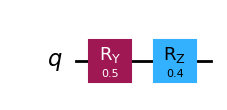

In [2]:
x = 0.25
theta = 0.4

qc = QuantumCircuit(1)
qc.ry(2 * x, 0)
qc.rz(theta, 0)

qc.draw("mpl")

In [3]:
sv = Statevector.from_instruction(qc)
qiskit_probs = sv.probabilities_dict()
qiskit_p1 = float(qiskit_probs.get("1", 0.0))

print("Qiskit probabilities:", qiskit_probs)
print("Qiskit scalar output P(1):", qiskit_p1)

Qiskit probabilities: {np.str_('0'): np.float64(0.9387912809451865), np.str_('1'): np.float64(0.06120871905481362)}
Qiskit scalar output P(1): 0.06120871905481362


### PennyLane version

0: ──RY(0.50)──RZ(0.40)─┤  Probs


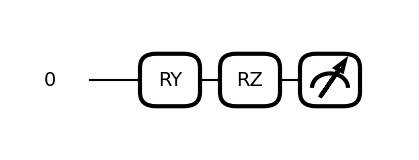

In [4]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def pl_circuit(x, theta):
    qml.RY(2 * x, wires=0)
    qml.RZ(theta, wires=0)
    return qml.probs(wires=0)

pl_probs = pl_circuit(x, theta)
pl_p1 = float(pl_probs[1])

print(qml.draw(pl_circuit)(x, theta))
fig, _ = qml.draw_mpl(pl_circuit)(x, theta)
fig.set_size_inches(4.0, 1.4)

In [5]:
print("PennyLane probabilities:", pl_probs)
print("PennyLane scalar output P(1):", pl_p1)

PennyLane probabilities: [0.93879128 0.06120872]
PennyLane scalar output P(1): 0.06120871905481364


Both implementations encode the same scalar input into one qubit, apply the same pair of single-qubit rotations, and return the probability of measuring $\ket{1}$. The first gate, $R_Y(2x)$, changes the amplitudes of $\ket{0}$ and $\ket{1}$, so it directly affects the measurement probabilities. The second gate, $R_Z(\theta)$, changes only the relative phase between computational-basis components; with a final probability measurement in the computational basis, that phase does not change $P(1)$. So in this minimal example the output is controlled by the input encoding more than by the trainable parameter, which is acceptable because the goal here is not expressivity, but API comparison.

What matters pedagogically is how each framework exposes the same computation. In Qiskit, we explicitly build a [`QuantumCircuit`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit), simulate it with [`Statevector`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector), read the probability dictionary, and then extract the scalar output $P(1)$. In PennyLane, we define a [`QNode`](https://docs.pennylane.ai/en/stable/code/api/pennylane.QNode.html) with [`qml.qnode`](https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html), specify [`qml.probs`](https://docs.pennylane.ai/en/stable/code/api/pennylane.probs.html) as the measurement, and directly obtain the probability vector as the return value of the quantum function. The numerical values match because both frameworks implement the same unitary transformation and the same measurement on an ideal simulator, up to ordinary floating-point precision.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Encoding note</b><br>
We write the feature as <code>x</code> and then apply <code>R_Y(2x)</code> because <code>x</code> is the classical input variable, while the gate still expects a rotation angle. For a one-qubit state prepared as $R_Y(\phi)\ket{0}$, the probability of measuring $\ket{1}$ is $\sin^2(\phi/2)$. So choosing $\phi = 2x$ makes the output become $P(1)=\sin^2(x)$, which is a simple and common encoding convention. In other words, we keep <code>x</code> as the feature and use <code>2x</code> as the angle derived from that feature.
</div>

### Task 1 (coding): Small parameter sweep in both frameworks

Using the complete examples above as templates, compare the same one-qubit circuit for several inputs and for two different values of the trainable parameter.

Use:
- `x_values = [0.0, 0.3, 0.6, 0.9]`
- `theta_values = [0.0, 1.2]`

Tasks:
- In **Qiskit**, compute $P(1)$ for every pair `(x, theta)`.
- In **PennyLane**, compute the same set of probabilities.
- Compare the Qiskit and PennyLane outputs for each pair.
- Check whether changing `theta` changes the measured probability in this example.
- Write two or three sentences summarizing what you observe about the roles of `x` and `theta` in this circuit.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="02-qiskitml-vs-pennylane-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>

In [6]:
# Task 1 starter
x_values = [0.0, 0.3, 0.6, 0.9]
theta_values = [0.0, 1.2]

# Reuse or adapt the Qiskit and PennyLane examples above.
# Suggested structure:
# 1. Build a small loop (or helper function) for Qiskit.
# 2. Build the analogous loop (or helper function) for PennyLane.
# 3. Print or store P(1) for each (x, theta) pair.
# 4. Compare the two frameworks and comment on whether theta affects P(1).

### Task 2 (optional coding): Same circuit, different measurement

Keep the **same one-qubit circuit structure** as in the example above, but now use the model output
$$
\langle Z \rangle
$$
instead of $P(1)$.

Use `x = 0.6` and `theta = 1.2`.

Tasks:
- In **Qiskit**, compute the expectation value $\langle Z \rangle$ for the circuit.
- In **PennyLane**, modify the measurement so the `QNode` returns $\langle Z \rangle$ directly.
- Compare the two numerical results.
- Check that your answer is consistent with the probability-based output through the identity $\langle Z \rangle = P(0) - P(1) = 1 - 2P(1)$.

Useful references:
- Qiskit [`Statevector`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector)
- PennyLane [`qml.expval`](https://docs.pennylane.ai/en/stable/code/api/pennylane.expval.html)
- PennyLane [`qml.Z`](https://docs.pennylane.ai/en/stable/code/api/pennylane.Z.html)

This task is optional, but it is useful because it begins to show an important software difference: the circuit can stay the same while the **measurement interface** changes.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="02-qiskitml-vs-pennylane-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>

In [7]:
# Task 2 starter
x = 0.6
theta = 1.2

# Keep the same circuit as before, but change the output quantity.
# Suggested structure:
# 1. In Qiskit, compute <Z> from the state or from the probabilities.
# 2. In PennyLane, define a QNode that returns qml.expval(qml.Z(0)).
# 3. Compare both results.
# 4. Verify that <Z> = 1 - 2 P(1).

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Why is $\langle Z \rangle = P(0) - P(1) = 1 - 2P(1)$?</b><br>
For one qubit, the Pauli-$Z$ observable has eigenvalue $+1$ on $\ket{0}$ and eigenvalue $-1$ on $\ket{1}$. Therefore, its expectation value is the probability-weighted average of those outcomes: $\langle Z \rangle = (+1)P(0) + (-1)P(1) = P(0) - P(1)$. Since probabilities add to one, $P(0)+P(1)=1$, we can also write $\langle Z \rangle = 1 - 2P(1)$.
</div>

## Framework selection is task-dependent

No framework is universally better. After the examples in this notebook, a more useful question is: **which framework fits the surrounding workflow better, not only the circuit itself?** We saw that the same one-qubit idea can be implemented in both frameworks, but the software experience is not identical.

<p align="center">
  <img align="center" src="./images/framework-selection-guide.png" alt="Framework selection guide for Qiskit Machine Learning and PennyLane" width="100%"/>
</p>

This decision map is only a guide, but it captures the main idea: the best choice often depends more on the workflow around the circuit than on the circuit alone.

A practical guide is:
- If you want a workflow centered on **Qiskit-native circuits, quantum kernels, QSVMs, or QNN estimators**, Qiskit Machine Learning is often the more direct choice.
- If you want a workflow centered on **QNodes, explicit measurement choices, and differentiable hybrid models**, PennyLane is often the more natural choice.
- If the task is small and exploratory, either framework may be perfectly reasonable; clarity, available examples, and ecosystem fit may matter more than raw features.

So the decision is usually less about whether one framework can express the circuit, and more about which framework makes the full modeling, measurement, and training workflow easier to build and understand.

### Task 3 (reflection): Match tasks to framework strengths

Consider the following five scenarios:
1. You want to build a QSVM or quantum-kernel workflow using Qiskit circuits and compare it against classical baselines.
2. You want to train a differentiable hybrid model and later connect it to a deep-learning workflow.
3. You already have a project built around Qiskit circuits and IBM Quantum-style backends, and now you want to add a variational classifier or kernel-based experiment without changing ecosystems too much.
4. You are prototyping a hybrid model in a notebook and expect to change the circuit outputs several times, for example from probabilities to expectation values, while keeping the same circuit structure.
5. You are preparing a short teaching or exploratory notebook on a small QML idea, and there is no strong dependency yet on either Qiskit or auto-diff frameworks.

For each scenario, choose `Qiskit Machine Learning`, `PennyLane`, or `both acceptable`, and justify your choice with two technical arguments.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="02-qiskitml-vs-pennylane-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>